# Large-sized Inversions
Here, we visualize the inversions that were identified for the `large` treatment across the range of depths for the **90% threshold** called variants. An extra consideration here is that with the deconvolution-during-concatenation step, Harpy was unable to call variants on the 10X and 20X data because there were too many molecules (more than the 96^4 possible with haplotagging).

In [2]:
library(ggplot2)
options(warn = -1)

read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan90", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan90", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- factor(c("simulated_inversions"))

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan90", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]
    sample_inversions$sample <- as.factor(sample_inversions$sample)
    if(file.exists(poolfile)){
        pooled_inversions <- read.table(poolfile, header = T)
        pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
        names(pooled_inversions)[1] <- "sample"
        if(nrow(pooled_inversions > 0)){
            pooled_inversions$sample <- factor(paste("pooled", depth, size_treatment, sep = "_"))
        }
    } else {
        # get an empty copy
        pooled_inversions <- sample_inversions[0, ]
    }
    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}
plot_data <- function(data, size_treatment, depth){
    axis_ticks <- c(paste0("sample_", sprintf("%02d", 1:10), ".", depth), "simulated_inversions", paste("pooled", depth, size_treatment, sep = "_"))
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"large"` to avoid writing it each time

In [3]:
.size <- "large"

## 0.5X depth

In [4]:
depth_05X <- read_data(.size, "05X")
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
3,2R,1439997,4186470,simulated_inversions
4,2R,21284517,22907265,simulated_inversions
5,3R,19738053,20951826,simulated_inversions
6,3R,21788248,26713174,simulated_inversions
7,3L,176550,2301734,simulated_inversions
8,3L,18163968,21883914,simulated_inversions


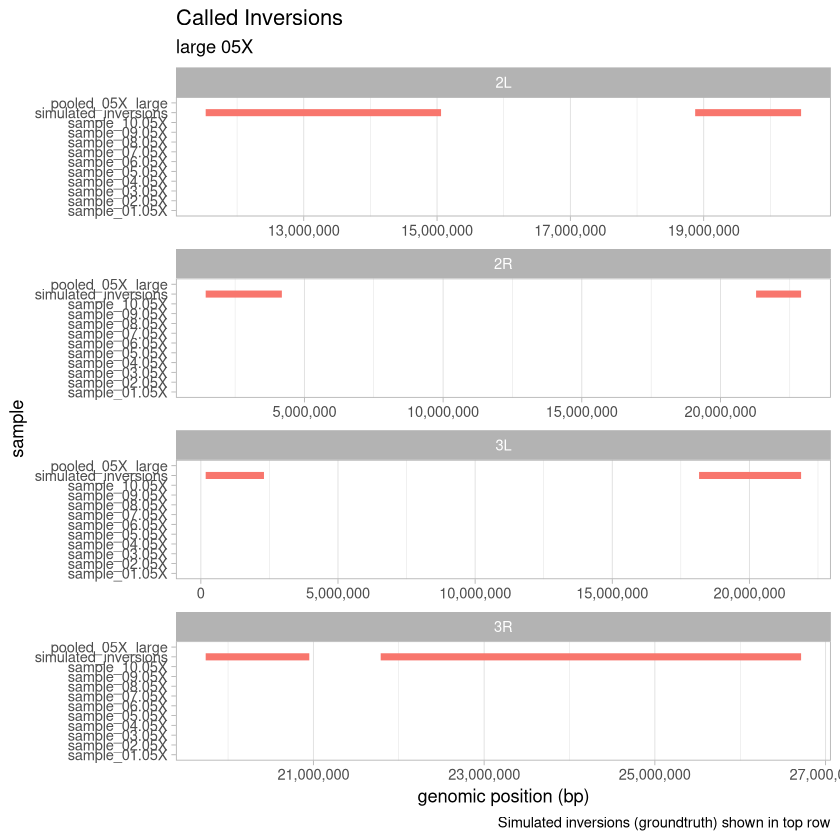

In [5]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [6]:
depth_2X <- read_data(.size, "2X")
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
21,3R,19738051,20951825,sample_02.2X
22,2L,18872128,20461266,sample_10.2X
23,2L,18872128,20461266,sample_04.2X
24,2R,21284515,22907265,sample_04.2X
25,3R,19738051,20951827,sample_04.2X
26,2L,18872128,20461266,sample_08.2X


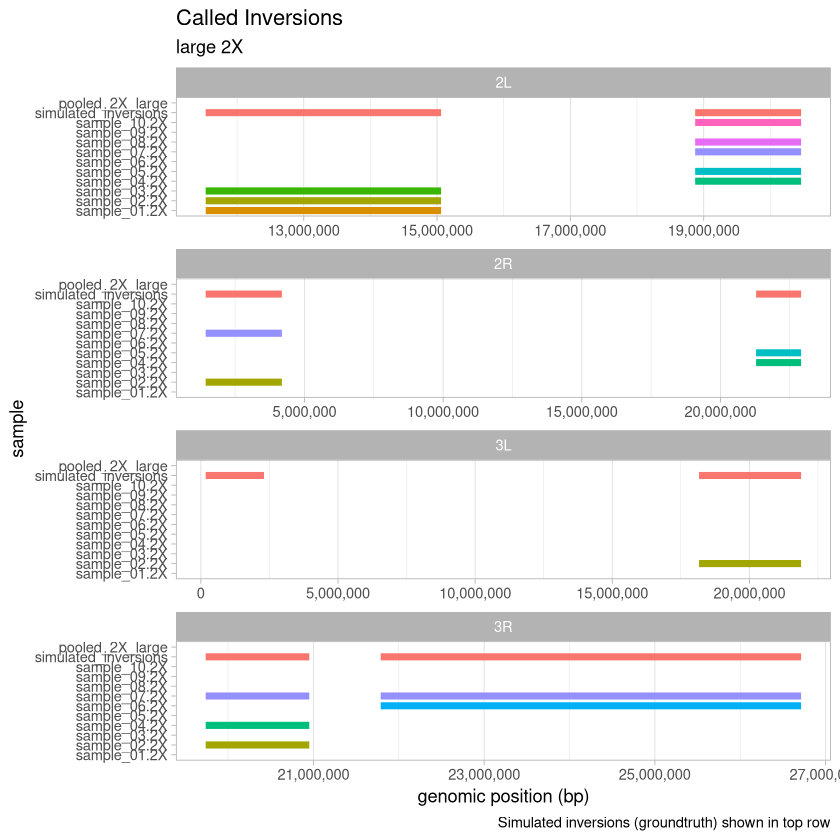

In [7]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [8]:
depth_5X <- read_data(.size, "5X")
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
45,2R,1439997,4186470,sample_08.5X
46,3R,21788247,26713174,sample_08.5X
47,2L,11529164,15060030,sample_06.5X
48,3L,176549,2301734,sample_06.5X
49,2R,21284515,22907266,sample_06.5X
50,3R,21788247,26713174,sample_06.5X


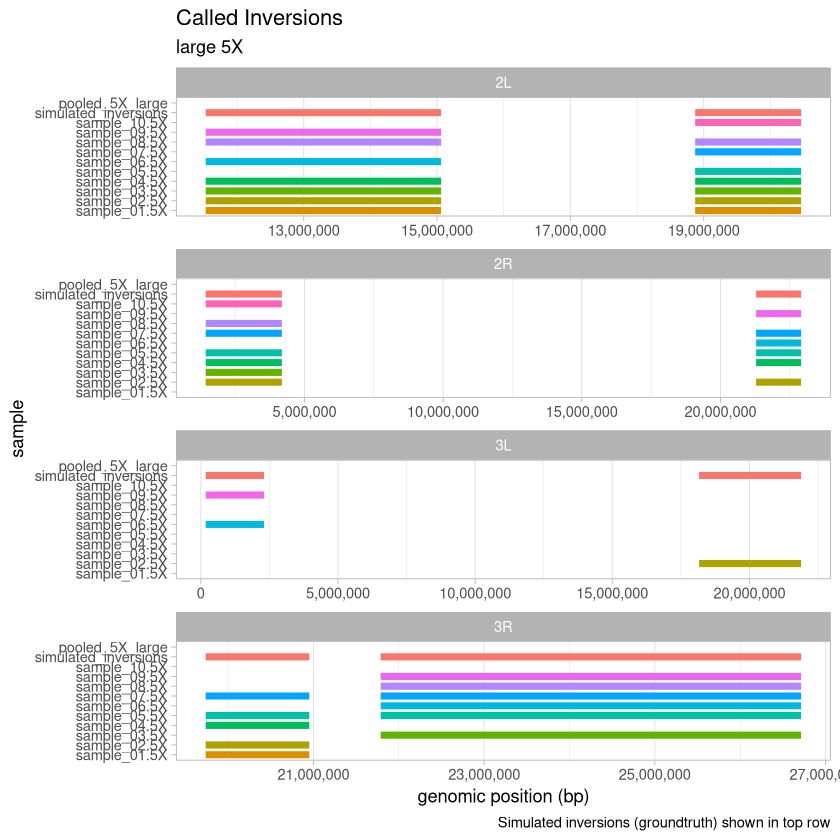

In [9]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [10]:
depth_10X <- read_data(.size, "10X")
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
61,2L,11529164,15060030,sample_03.10X
62,2L,18872128,20461266,sample_03.10X
63,2R,1439996,4186470,sample_03.10X
64,2R,21284515,22907266,sample_03.10X
65,3R,19738053,20951827,sample_03.10X
66,3R,21788246,26713174,sample_03.10X


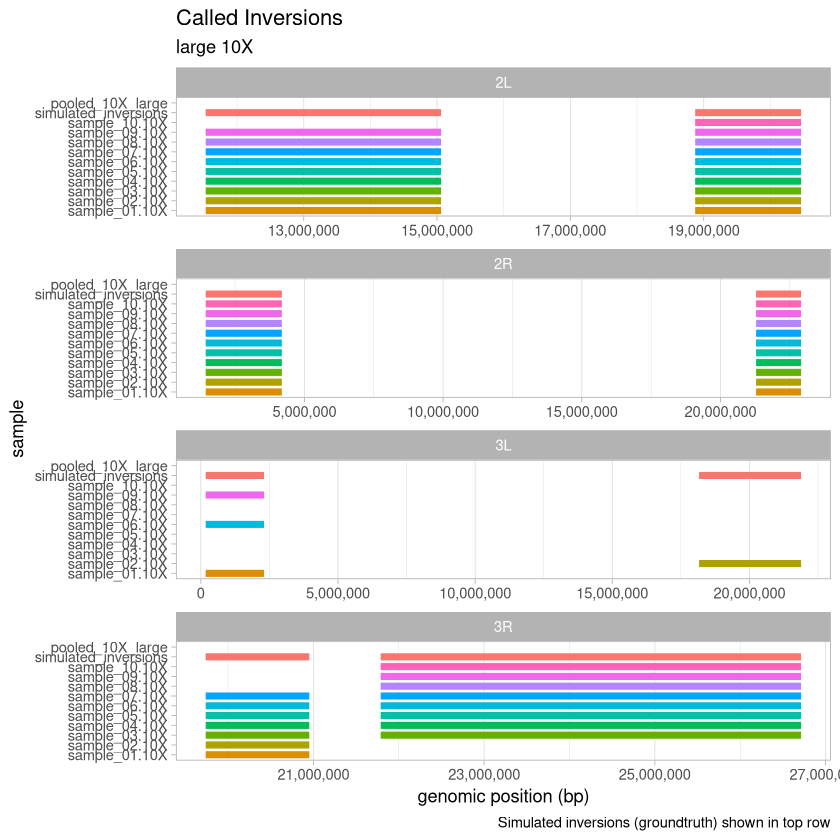

In [11]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [12]:
depth_20X <- read_data(.size, "20X")
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
62,2L,11529164,15060030,sample_07.20X
63,2L,18872128,20461266,sample_07.20X
64,2R,1439996,4186470,sample_07.20X
65,2R,21284515,22907266,sample_07.20X
66,3R,19738051,20951825,sample_07.20X
67,3R,21788246,26713174,sample_07.20X


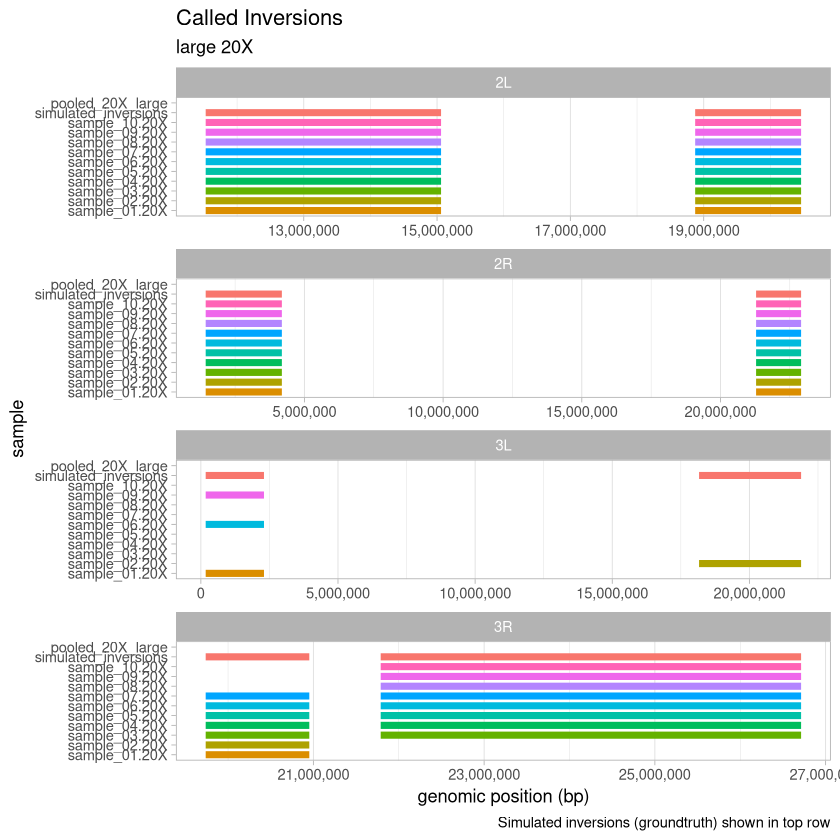

In [13]:
plot_data(depth_20X, .size, "20X")